# Theoretical Reconstruction Limits: PCA vs Autoencoders

measures the reconstruction ceiling of PCA and trained autoencoders at various
latent dimensionalities on the DEG+HVG gene set. for each method and dimension:
project to latent space, reconstruct back to gene space, compute cosine_logfc and
W2 against original. shows how much perturbation signal each method preserves
at each compression level.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.decomposition import PCA

from flatcfm.analysis.benchmarks.metrics import compute_mean_gene_w1, compute_w2_squared
from flatcfm.data.space import load_ae_projection

# dimensions to sweep
AE_DIMS = [16, 32, 64, 128, 256, 512, 1024]
PCA_DIMS = [16, 32, 64, 128, 256, 512, 1024, 2000, 5000]  # plus full dim

# AE variants to compare
# mse is the original 3-layer hidden=256 architecture (architectural bottleneck flat curve)
# mse_wide scales hidden_dim with latent_dim (5 layers, hidden>=max(512, 2*latent))
# so the architectural bottleneck is the latent dim not the hidden dim
# linear is two nn.Linear layers with no nonlinearity, should match PCA exactly
# and serves as the diagnostic baseline that isolates the nonlinearity as the
# cause of the nonlinear-AE plateau
#
# per variant optional fields
#   dims        list of latent dims overriding AE_DIMS for variants that have
#               not been swept at every dim (single point variant shows up as
#               one marker on the x axis)
#   tag_by_dim  {dim: explicit_tag} override when the saved artifact does not
#               follow the default sciplex_ae_deg_{variant_key}_d{dim} pattern
VARIANTS = {
    "mse": {"label": "MSE AE (narrow h=256)", "color": "#EE6677", "marker": "s"},
    "mse_wide": {"label": "MSE AE (wide)", "color": "#882255", "marker": "X"},
    "linear": {"label": "Linear AE", "color": "#117733", "marker": "P"},
    "nb": {"label": "NB AE", "color": "#CCBB44", "marker": "p"},
    "flatvi": {"label": "FlatVI AE", "color": "#228833", "marker": "^"},
    "phate_nb": {"label": "PHATE NB AE", "color": "#AA3377", "marker": "D"},
    "phate_mse": {"label": "PHATE MSE AE", "color": "#EE7733", "marker": "*"},
}
PCA_STYLE = {"label": "PCA", "color": "#4477AA", "marker": "o"}


def variant_dims(variant_cfg: dict) -> list[int]:
    """latent dims to sweep for a variant defaults to AE_DIMS"""
    return list(variant_cfg.get("dims", AE_DIMS))


def variant_tag(variant_key: str, variant_cfg: dict, dim: int) -> str:
    """resolve the saved artifact tag for a variant at a given latent dim"""
    tag_by_dim = variant_cfg.get("tag_by_dim")
    if tag_by_dim and dim in tag_by_dim:
        return tag_by_dim[dim]
    return f"sciplex_ae_deg_{variant_key}_d{dim}"


In [2]:
# load datamodule to get the same train/test split and feature set
from hydra.utils import instantiate
from omegaconf import OmegaConf

experiment_name = "sciplex_ae_deg_log1p_recon"
runs_root = Path("artifacts/runs")
run_root = runs_root / experiment_name
run_dirs = sorted(p for p in run_root.glob("*") if p.is_dir())
if not run_dirs:
    raise FileNotFoundError(f"No runs found under {run_root}")
run_dir = run_dirs[-1]
cfg = OmegaConf.load(run_dir / "run_config.yaml")

datamodule = instantiate(
    cfg.data,
    data=OmegaConf.to_container(cfg.data, resolve=True),
    splitter=OmegaConf.to_container(cfg.splitter, resolve=True),
    space=OmegaConf.to_container(cfg.space, resolve=True),
    evaluation_space=OmegaConf.to_container(cfg.evaluation_space, resolve=True),
    condition=OmegaConf.to_container(cfg.condition, resolve=True),
    paths=OmegaConf.to_container(cfg.paths, resolve=True),
    ae_geometry=OmegaConf.to_container(cfg.ae_geometry, resolve=True),
    task=OmegaConf.to_container(cfg.task, resolve=True),
    predict=OmegaConf.to_container(cfg.predict, resolve=True),
    trainer=OmegaConf.to_container(cfg.trainer, resolve=True),
    _recursive_=False,
)
datamodule.setup("fit")

held_out_mask = np.asarray(datamodule.masks["is_held_out"], dtype=bool)
test_adata = datamodule.adata_full[held_out_mask].copy()
train_adata = datamodule.adata_full[~held_out_mask].copy()

x_train, lib_train, feature_names = datamodule.train_pipeline.transform(train_adata, device="cpu")
x_test, lib_test, _ = datamodule.train_pipeline.transform(test_adata, device="cpu")
x_train = np.asarray(x_train, dtype=np.float32)
x_test = np.asarray(x_test, dtype=np.float32)
lib_test = np.asarray(lib_test, dtype=np.float32)
feature_names = list(feature_names)

schema = datamodule.schema
perturbation_key = str(schema.perturbation_source)
control_column = str(schema.control_column)
control_value = str(schema.control_value)
covariate_keys = tuple(str(cov.source_column) for cov in schema.sample_covariates)
dose_key = "dose"

print(f"train: {x_train.shape}, test: {x_test.shape}")
print(f"features: {len(feature_names)}")

train: (87775, 6396), test: (12225, 6396)
features: 6396


In [3]:
from flatcfm._utils import dense_array

# build control means per cell type
all_control_mask = datamodule.adata_full.obs[control_column].astype(str).to_numpy() == control_value
all_control_adata = datamodule.adata_full[all_control_mask].copy()
x_ctrl, _, _ = datamodule.train_pipeline.transform(all_control_adata, device="cpu")
x_ctrl = np.asarray(x_ctrl, dtype=np.float32)
ctrl_obs = all_control_adata.obs.copy().reset_index(drop=True)

ctrl_means = {}
for ct in ctrl_obs["cell_type"].astype(str).unique():
    m = ctrl_obs["cell_type"].astype(str).to_numpy() == ct
    ctrl_means[ct] = x_ctrl[m].mean(axis=0)

# group perturbed test cells
test_obs = test_adata.obs.copy().reset_index(drop=True)
pert_mask = test_obs[control_column].astype(str).to_numpy() != control_value
pert_obs = test_obs.loc[pert_mask].reset_index(drop=True)
x_test_pert = x_test[pert_mask]
lib_test_pert = lib_test[pert_mask]

group_columns = [*covariate_keys, perturbation_key, dose_key]
group_keys = []
group_slices = []
for _, grp in pert_obs.groupby(list(group_columns), observed=True):
    if len(grp) < 2:
        continue
    group_keys.append({col: str(grp.iloc[0][col]) for col in group_columns})
    group_slices.append(grp.index.to_numpy())

# precompute original logfcs
orig_logfcs = np.array(
    [
        x_test_pert[idx].mean(axis=0) - ctrl_means.get(gk.get("cell_type", ""), x_ctrl.mean(axis=0))
        for gk, idx in zip(group_keys, group_slices)
    ]
)
valid_group_mask = np.array([np.linalg.norm(lfc) > 1e-8 for lfc in orig_logfcs])

print(f"perturbation groups: {len(group_keys)}")
print(f"perturbed test cells: {pert_mask.sum()}")
print(f"valid groups: {valid_group_mask.sum()}")

perturbation groups: 375
perturbed test cells: 12225
valid groups: 375


In [4]:
def compute_reconstruction_metrics(
    x_recon: np.ndarray,
    method_name: str,
    latent_dim: int,
    var_explained_override: float | None = None,
    pca_50_orig: np.ndarray | None = None,
    pca_50_recon: np.ndarray | None = None,
) -> list[dict]:
    """compute cosine_logfc, W2, mean_gene_w1, and MMD (PCA-50) for a reconstruction vs original"""
    from flatcfm.analysis.benchmarks.metrics import compute_mmd

    # empirical variance explained
    if var_explained_override is not None:
        var_explained = var_explained_override
    else:
        mse = np.mean((x_test_pert - x_recon) ** 2)
        var_x = np.var(x_test_pert)
        var_explained = 1.0 - mse / var_x

    # vectorized cosine_logfc
    recon_logfcs = np.array(
        [
            x_recon[idx].mean(axis=0) - ctrl_means.get(gk.get("cell_type", ""), x_ctrl.mean(axis=0))
            for gk, idx in zip(group_keys, group_slices)
        ]
    )
    dots = np.sum(orig_logfcs * recon_logfcs, axis=1)
    norms_orig = np.linalg.norm(orig_logfcs, axis=1)
    norms_recon = np.linalg.norm(recon_logfcs, axis=1)
    cosines = dots / (norms_orig * norms_recon + 1e-12)

    results = []
    for i, (gk, idx) in enumerate(zip(group_keys, group_slices)):
        if not valid_group_mask[i]:
            continue
        w2 = np.sqrt(compute_w2_squared(x_test_pert[idx], x_recon[idx]))
        mean_w1 = compute_mean_gene_w1(x_test_pert[idx], x_recon[idx])

        row = {
            "method": method_name,
            "latent_dim": latent_dim,
            "var_explained": var_explained,
            **gk,
            "n_cells": len(idx),
            "cosine_logfc": float(cosines[i]),
            "w2": float(w2),
            "mean_gene_w1": float(mean_w1),
        }

        # MMD in PCA-50 space if projections provided
        if pca_50_orig is not None and pca_50_recon is not None:
            row["mmd_pca50"] = float(compute_mmd(pca_50_orig[idx], pca_50_recon[idx]))

        results.append(row)
    return results

In [5]:
# compute PCA theoretical limits (cached to avoid recomputation)
import json as _json


def _json_default(obj):
    if hasattr(obj, "item"):
        return obj.item()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")


CACHE_DIR = Path("artifacts/theoretical_limits_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
pca_cache = CACHE_DIR / "pca_results.json"

# fit PCA-50 for MMD comparison space (always needed)
pca_50 = PCA(n_components=50)
pca_50.fit(x_train)
pca_50_orig = pca_50.transform(x_test_pert)

# check if cache has mmd_pca50
cache_has_mmd = False
if pca_cache.exists():
    _cached = _json.loads(pca_cache.read_text())
    cache_has_mmd = len(_cached) > 0 and "mmd_pca50" in _cached[0]
    del _cached

if pca_cache.exists() and cache_has_mmd:
    pca_results = _json.loads(pca_cache.read_text())
    print(f"loaded {len(pca_results)} cached PCA results from {pca_cache}")
else:
    if pca_cache.exists():
        print("cache missing mmd_pca50, recomputing...")
    n_features = x_train.shape[1]
    pca_dims = [d for d in PCA_DIMS if d < n_features] + [n_features]

    pca_results = []
    for n_comp in pca_dims:
        label = str(n_comp) if n_comp < n_features else "all"
        print(f"PCA d={label}...", end=" ")

        if n_comp >= n_features:
            x_recon = x_test_pert
            var_explained = 1.0
        else:
            pca = PCA(n_components=n_comp, svd_solver="randomized" if n_comp >= 256 else "auto", random_state=0)
            pca.fit(x_train)
            x_recon = pca.inverse_transform(pca.transform(x_test_pert))
            var_explained = float(pca.explained_variance_ratio_.sum())

        pca_50_recon = pca_50.transform(x_recon)

        pca_results.extend(
            compute_reconstruction_metrics(
                x_recon,
                method_name="PCA",
                latent_dim=n_comp,
                var_explained_override=var_explained,
                pca_50_orig=pca_50_orig,
                pca_50_recon=pca_50_recon,
            )
        )
        mean_cos = np.mean([r["cosine_logfc"] for r in pca_results if r["latent_dim"] == n_comp])
        mean_mmd = np.mean([r["mmd_pca50"] for r in pca_results if r["latent_dim"] == n_comp])
        print(f"var_exp={var_explained:.4f}, cos={mean_cos:.4f}, mmd_pca50={mean_mmd:.4f}")

    pca_cache.write_text(_json.dumps(pca_results, default=_json_default))
    print(f"\nsaved {len(pca_results)} PCA results to {pca_cache}")

print(f"PCA results: {len(pca_results)}")

loaded 3750 cached PCA results from artifacts/theoretical_limits_cache/pca_results.json
PCA results: 3750


In [6]:
# compute AE theoretical limits (cached per variant+dim)
device = "cuda" if torch.cuda.is_available() else "cpu"
spaces_root = Path("artifacts/spaces")
ae_cache = CACHE_DIR / "ae_results.json"

# load existing cache keyed by method_dim
cached_ae: dict[str, list[dict]] = {}
if ae_cache.exists():
    for r in _json.loads(ae_cache.read_text()):
        key = f"{r['method']}_{r['latent_dim']}"
        cached_ae.setdefault(key, []).append(r)

ae_results = []
new_computed = False
for variant_key, variant_cfg in VARIANTS.items():
    for dim in variant_dims(variant_cfg):
        cache_key = f"{variant_cfg['label']}_{dim}"
        if cache_key in cached_ae:
            ae_results.extend(cached_ae[cache_key])
            print(f"{variant_cfg['label']} d={dim}... cached")
            continue

        tag = variant_tag(variant_key, variant_cfg, dim)
        pkl_files = list(spaces_root.glob(f"sciplex_ae_projection_*_{tag}.pkl"))
        if not pkl_files:
            print(f"SKIP {variant_cfg['label']} d={dim}: no projection pickle")
            continue

        print(f"{variant_cfg['label']} d={dim}...", end=" ")
        projection = load_ae_projection(pkl_files[0])
        ae_model = projection.ae_model.to(device)
        ae_model.eval()

        with torch.no_grad():
            x_tensor = torch.as_tensor(x_test_pert, dtype=torch.float32, device=device)
            lib_tensor = torch.as_tensor(lib_test_pert, dtype=torch.float32, device=device)
            z = ae_model.encode(x_tensor)
            x_recon_tensor = ae_model.reconstruct_input(z, lib_tensor)
            x_recon = x_recon_tensor.cpu().numpy()

        results = compute_reconstruction_metrics(
            x_recon,
            method_name=variant_cfg["label"],
            latent_dim=dim,
        )
        ae_results.extend(results)
        new_computed = True
        mean_cos = np.mean([r["cosine_logfc"] for r in results])
        mean_ve = results[0]["var_explained"] if results else 0.0
        print(f"var_exp={mean_ve:.4f}, cos={mean_cos:.4f}")

        del ae_model, projection
        torch.cuda.empty_cache()

if new_computed:
    ae_cache.write_text(_json.dumps(ae_results, default=_json_default))
    print(f"saved ae cache to {ae_cache}")
print(f"\nAE results: {len(ae_results)}")


/home/dac227/scratch_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:1007: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


MSE AE (narrow h=256) d=16... cached
MSE AE (narrow h=256) d=32... cached
MSE AE (narrow h=256) d=64... cached
MSE AE (narrow h=256) d=128... cached
MSE AE (narrow h=256) d=256... cached
MSE AE (narrow h=256) d=512... cached
MSE AE (narrow h=256) d=1024... cached
MSE AE (wide) d=16... cached
MSE AE (wide) d=32... cached
MSE AE (wide) d=64... cached
MSE AE (wide) d=128... cached
MSE AE (wide) d=256... cached
MSE AE (wide) d=512... cached
MSE AE (wide) d=1024... cached
Linear AE d=16... cached
Linear AE d=32... cached
Linear AE d=64... cached
Linear AE d=128... cached
Linear AE d=256... cached
Linear AE d=512... cached
Linear AE d=1024... cached
NB AE d=16... cached
SKIP NB AE d=32: no projection pickle
SKIP NB AE d=64: no projection pickle
NB AE d=128... cached
SKIP NB AE d=256: no projection pickle
SKIP NB AE d=512: no projection pickle
SKIP NB AE d=1024: no projection pickle
SKIP FlatVI AE d=16: no projection pickle
SKIP FlatVI AE d=32: no projection pickle
SKIP FlatVI AE d=64: no pro

In [7]:
all_results = pd.DataFrame(pca_results + ae_results)
summary = (
    all_results.groupby(["method", "latent_dim", "var_explained"])
    .agg(
        cosine_logfc_mean=("cosine_logfc", "mean"),
        cosine_logfc_std=("cosine_logfc", "std"),
        w2_mean=("w2", "mean"),
        w2_std=("w2", "std"),
        mean_gene_w1_mean=("mean_gene_w1", "mean")
        if "mean_gene_w1" in all_results.columns
        else ("cosine_logfc", "count"),
        mean_gene_w1_std=("mean_gene_w1", "std")
        if "mean_gene_w1" in all_results.columns
        else ("cosine_logfc", "count"),
        n_groups=("cosine_logfc", "count"),
    )
    .reset_index()
    .sort_values(["method", "latent_dim"])
)
display(summary)

,method,latent_dim,var_explained,cosine_logfc_mean,cosine_logfc_std,w2_mean,w2_std,mean_gene_w1_mean,mean_gene_w1_std,n_groups
0,Linear AE,16,0.236225,0.313072,7.659492e-02,45.465398,8.460610e-01,0.246048,0.009694,375
1,Linear AE,32,0.247106,0.341492,7.971795e-02,45.137650,8.482820e-01,0.242629,0.009390,375
2,Linear AE,64,0.263357,0.371204,7.844768e-02,44.644776,8.416728e-01,0.238818,0.009219,375
3,Linear AE,128,0.290496,0.401238,7.488663e-02,43.814365,8.242553e-01,0.234538,0.008794,375
4,Linear AE,256,0.336788,0.442798,7.025777e-02,42.360819,7.982007e-01,0.229756,0.008263,375
5,Linear AE,512,0.416724,0.543381,5.553837e-02,39.726208,7.519742e-01,0.217241,0.007089,375
6,Linear AE,1024,0.546671,0.695959,3.162762e-02,35.030857,6.867452e-01,0.199395,0.005839,375
7,MSE AE (narrow h=256),16,0.244581,0.328138,1.033562e-01,45.209126,8.528079e-01,0.224511,0.010242,375
8,MSE AE (narrow h=256),32,0.250970,0.335232,1.034442e-01,45.017926,8.602544e-01,0.223406,0.009932,375
9,MSE AE (narrow h=256),64,0.252751,0.340761,1.033031e-01,44.961763,8.491326e-01,0.220168,0.010447,375


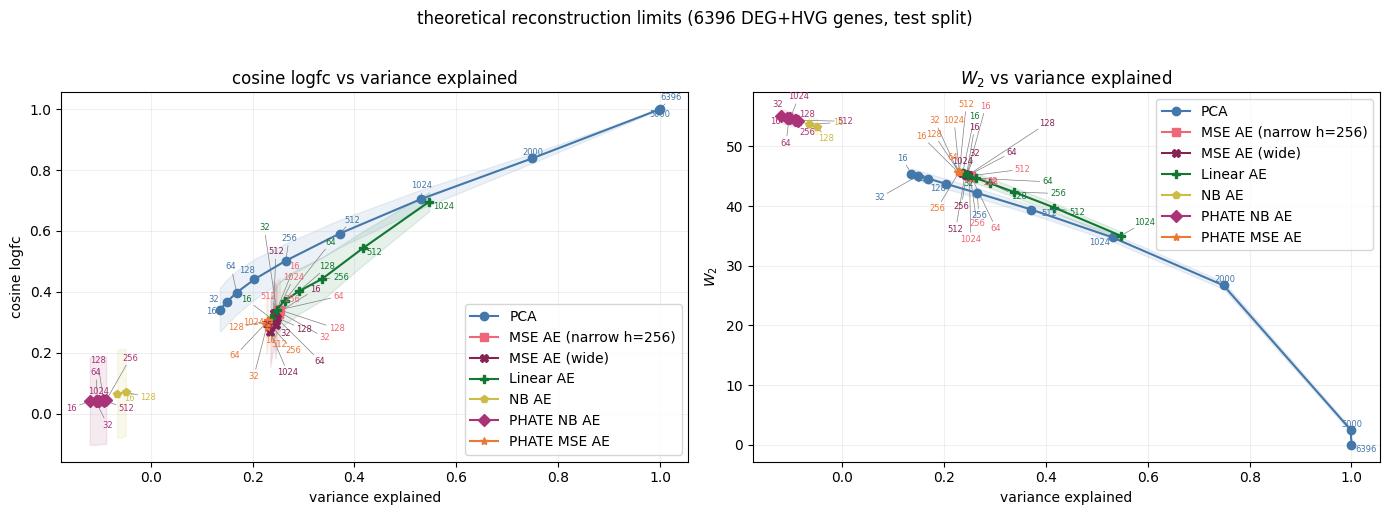

In [8]:
# main comparison: metrics vs variance explained
from adjustText import adjust_text

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = {"PCA": PCA_STYLE, **{v["label"]: v for v in VARIANTS.values()}}

for ax_idx, (metric_col, metric_std, ylabel, title) in enumerate(
    [
        ("cosine_logfc_mean", "cosine_logfc_std", "cosine logfc", "cosine logfc vs variance explained"),
        ("w2_mean", "w2_std", "$W_2$", "$W_2$ vs variance explained"),
    ]
):
    ax = axes[ax_idx]
    texts = []
    for method_name, style in methods.items():
        s = summary[summary["method"] == method_name].sort_values("var_explained")
        if s.empty:
            continue

        ax.plot(
            s["var_explained"],
            s[metric_col],
            marker=style["marker"],
            color=style["color"],
            label=style["label"],
            markersize=6,
        )
        ax.fill_between(
            s["var_explained"],
            s[metric_col] - s[metric_std],
            s[metric_col] + s[metric_std],
            alpha=0.1,
            color=style["color"],
        )
        for _, row in s.iterrows():
            texts.append(
                ax.annotate(
                    str(int(row["latent_dim"])),
                    (row["var_explained"], row[metric_col]),
                    fontsize=6,
                    ha="center",
                    color=style["color"],
                )
            )

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        force_text=(0.6, 1.2),
        force_static=(0.2, 0.4),
        expand_axes=True,
        only_move={"text": "xy", "static": "xy"},
        max_move=60,
    )

    ax.set_xlabel("variance explained")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.2)

plt.suptitle(f"theoretical reconstruction limits ({len(feature_names)} DEG+HVG genes, test split)", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# count-space per-group metrics
# computes cosine_logfc, W2, and z-scored cosine_logfc in count space
# AE: reconstruct_counts(z, lib) gives NB mean in count space
# PCA: invert log1p reconstruction via expm1 + scale by lib/target_sum

# build count-space control means and stds per cell type
# subset to controls FIRST while still sparse then densify to avoid OOM on full matrix
all_ctrl_mask_full = datamodule.adata_full.obs[control_column].astype(str).to_numpy() == control_value
ctrl_adata_sparse = datamodule.adata_full[all_ctrl_mask_full]
x_raw_ctrl_sparse = ctrl_adata_sparse.X
if hasattr(x_raw_ctrl_sparse, "toarray"):
    x_raw_ctrl_sparse = x_raw_ctrl_sparse.toarray()
x_raw_ctrl_full = np.asarray(x_raw_ctrl_sparse, dtype=np.float32)[:, hvg_col_idx]
ctrl_obs_full = ctrl_adata_sparse.obs.reset_index(drop=True)

ctrl_means_counts = {}
for ct in ctrl_obs_full["cell_type"].astype(str).unique():
    m = ctrl_obs_full["cell_type"].astype(str).to_numpy() == ct
    ctrl_means_counts[ct] = x_raw_ctrl_full[m].mean(axis=0)
x_raw_ctrl_fallback = x_raw_ctrl_full.mean(axis=0)

# per-gene std of control counts (single global std across all control cells)
# used to z-score per-gene logfc so housekeeping genes do not dominate cosine
gene_std_counts = x_raw_ctrl_full.std(axis=0).astype(np.float32) + 1e-8

del x_raw_ctrl_sparse, x_raw_ctrl_full, ctrl_adata_sparse
import gc as _gc

_gc.collect()

# precompute original count-space logfcs per group (raw and z-scored)
orig_logfcs_counts = np.array(
    [
        x_raw_test_pert[idx].mean(axis=0) - ctrl_means_counts.get(gk.get("cell_type", ""), x_raw_ctrl_fallback)
        for gk, idx in zip(group_keys, group_slices)
    ]
)
orig_logfcs_counts_z = orig_logfcs_counts / gene_std_counts[None, :]
valid_group_mask_counts = np.array([np.linalg.norm(lfc) > 1e-8 for lfc in orig_logfcs_counts])


def compute_count_reconstruction_metrics(
    counts_recon: np.ndarray,
    method_name: str,
    latent_dim: int,
) -> list[dict]:
    """compute cosine_logfc, W2, and z-scored cosine_logfc per group in count space"""

    recon_logfcs = np.array(
        [
            counts_recon[idx].mean(axis=0) - ctrl_means_counts.get(gk.get("cell_type", ""), x_raw_ctrl_fallback)
            for gk, idx in zip(group_keys, group_slices)
        ]
    )
    dots = np.sum(orig_logfcs_counts * recon_logfcs, axis=1)
    norms_orig = np.linalg.norm(orig_logfcs_counts, axis=1)
    norms_recon = np.linalg.norm(recon_logfcs, axis=1)
    cosines = dots / (norms_orig * norms_recon + 1e-12)

    recon_logfcs_z = recon_logfcs / gene_std_counts[None, :]
    dots_z = np.sum(orig_logfcs_counts_z * recon_logfcs_z, axis=1)
    norms_orig_z = np.linalg.norm(orig_logfcs_counts_z, axis=1)
    norms_recon_z = np.linalg.norm(recon_logfcs_z, axis=1)
    cosines_z = dots_z / (norms_orig_z * norms_recon_z + 1e-12)

    mse = float(np.mean((x_raw_test_pert - counts_recon) ** 2))
    var_x = float(np.var(x_raw_test_pert))
    var_explained_counts = 1.0 - mse / var_x

    results = []
    for i, (gk, idx) in enumerate(zip(group_keys, group_slices)):
        if not valid_group_mask_counts[i]:
            continue
        w2 = float(np.sqrt(compute_w2_squared(x_raw_test_pert[idx], counts_recon[idx])))
        results.append(
            {
                "method": method_name,
                "latent_dim": latent_dim,
                "var_explained_counts": var_explained_counts,
                **gk,
                "n_cells": len(idx),
                "cosine_logfc_counts": float(cosines[i]),
                "cosine_logfc_counts_z": float(cosines_z[i]),
                "w2_counts": w2,
            }
        )
    return results


count_per_group_rows = []

# AE variants: use reconstruct_counts directly
for variant_key, variant_cfg in VARIANTS.items():
    for dim in variant_dims(variant_cfg):
        tag = variant_tag(variant_key, variant_cfg, dim)
        pkl_files = list(spaces_root.glob(f"sciplex_ae_projection_*_{tag}.pkl"))
        if not pkl_files:
            continue
        projection = load_ae_projection(pkl_files[0])
        ae_model = projection.ae_model.to(device)
        ae_model.eval()
        if not hasattr(ae_model, "reconstruct_counts"):
            del ae_model, projection
            continue
        with torch.no_grad():
            x_tensor = torch.as_tensor(x_test_pert, dtype=torch.float32, device=device)
            lib_tensor = torch.as_tensor(lib_test_pert, dtype=torch.float32, device=device)
            z = ae_model.encode(x_tensor)
            counts_recon = ae_model.reconstruct_counts(z, lib_tensor, sample=False).cpu().numpy().astype(np.float32)
        count_per_group_rows.extend(compute_count_reconstruction_metrics(counts_recon, variant_cfg["label"], dim))
        del ae_model, projection, counts_recon
        torch.cuda.empty_cache()
        _gc.collect()

# PCA: reconstruct in log1p space then invert to count space
pca_target_sum = 1e4
for n_comp in PCA_DIMS:
    if n_comp >= x_train.shape[1]:
        continue
    pca = PCA(n_components=n_comp, svd_solver="randomized" if n_comp >= 256 else "auto", random_state=0)
    pca.fit(x_train)
    x_recon_log1p = pca.inverse_transform(pca.transform(x_test_pert))
    counts_recon_pca = (np.expm1(x_recon_log1p).clip(min=0.0) * lib_test_pert[:, None] / pca_target_sum).astype(
        np.float32
    )
    count_per_group_rows.extend(compute_count_reconstruction_metrics(counts_recon_pca, "PCA", n_comp))
    del pca, x_recon_log1p, counts_recon_pca
    _gc.collect()

count_per_group_df = pd.DataFrame(count_per_group_rows)
summary_counts = (
    count_per_group_df.groupby(["method", "latent_dim", "var_explained_counts"])
    .agg(
        cosine_logfc_counts_mean=("cosine_logfc_counts", "mean"),
        cosine_logfc_counts_std=("cosine_logfc_counts", "std"),
        cosine_logfc_counts_z_mean=("cosine_logfc_counts_z", "mean"),
        cosine_logfc_counts_z_std=("cosine_logfc_counts_z", "std"),
        w2_counts_mean=("w2_counts", "mean"),
        w2_counts_std=("w2_counts", "std"),
        n_groups=("cosine_logfc_counts", "count"),
    )
    .reset_index()
    .sort_values(["method", "latent_dim"])
)
display(summary_counts)


NameError: name 'hvg_col_idx' is not defined

In [ ]:
# count-space comparison plot: cosine_logfc, z-scored cosine_logfc, and W2 vs variance explained
# plus a second row: variance explained (count space) vs latent dimension

fig, axes = plt.subplots(2, 3, figsize=(21, 10))

methods = {"PCA": PCA_STYLE, **{v["label"]: v for v in VARIANTS.values()}}

panels = [
    (
        "cosine_logfc_counts_mean",
        "cosine_logfc_counts_std",
        "cosine logfc (counts)",
        "cosine logfc vs variance explained (count space)",
    ),
    (
        "cosine_logfc_counts_z_mean",
        "cosine_logfc_counts_z_std",
        "cosine logfc (z-scored counts)",
        "z-scored cosine logfc vs variance explained (count space)",
    ),
    ("w2_counts_mean", "w2_counts_std", "$W_2$ (counts)", "$W_2$ vs variance explained (count space)"),
]

# top row: metric vs variance explained
for ax_idx, (metric_col, metric_std, ylabel, title) in enumerate(panels):
    ax = axes[0, ax_idx]
    texts = []
    for method_name, style in methods.items():
        s = summary_counts[summary_counts["method"] == method_name].sort_values("var_explained_counts")
        if s.empty:
            continue
        ax.plot(
            s["var_explained_counts"],
            s[metric_col],
            marker=style["marker"],
            color=style["color"],
            label=style["label"],
            markersize=6,
        )
        ax.fill_between(
            s["var_explained_counts"],
            s[metric_col] - s[metric_std],
            s[metric_col] + s[metric_std],
            alpha=0.1,
            color=style["color"],
        )
        for _, row in s.iterrows():
            texts.append(
                ax.annotate(
                    str(int(row["latent_dim"])),
                    (row["var_explained_counts"], row[metric_col]),
                    fontsize=6,
                    ha="center",
                    color=style["color"],
                )
            )
    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
        force_text=(0.6, 1.2),
        force_static=(0.2, 0.4),
        expand_axes=True,
        only_move={"text": "xy", "static": "xy"},
        max_move=60,
    )

    ax.set_xlabel("variance explained (count space)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

# bottom row: metric vs latent dimension (linear x-axis)
for ax_idx, (metric_col, metric_std, ylabel, _) in enumerate(panels):
    ax = axes[1, ax_idx]
    for method_name, style in methods.items():
        s = summary_counts[summary_counts["method"] == method_name].sort_values("latent_dim")
        if s.empty:
            continue
        ax.plot(
            s["latent_dim"],
            s[metric_col],
            marker=style["marker"],
            color=style["color"],
            label=style["label"],
            markersize=6,
        )
        ax.fill_between(
            s["latent_dim"],
            s[metric_col] - s[metric_std],
            s[metric_col] + s[metric_std],
            alpha=0.1,
            color=style["color"],
        )
    ax.set_xlabel("latent dimension")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs latent dimension")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

# variance explained vs latent dimension as a separate figure below
plt.suptitle(
    f"theoretical reconstruction limits in count space ({len(feature_names)} DEG+HVG genes, test split)", y=1.00
)
plt.tight_layout()
plt.show()

# separate figure: var_explained (count space) vs latent dim - linear x axis
fig2, ax2 = plt.subplots(figsize=(8, 5))
for method_name, style in methods.items():
    s = summary_counts[summary_counts["method"] == method_name].sort_values("latent_dim")
    if s.empty:
        continue
    ax2.plot(
        s["latent_dim"],
        s["var_explained_counts"],
        marker=style["marker"],
        color=style["color"],
        label=style["label"],
        markersize=6,
    )
ax2.set_xlabel("latent dimension")
ax2.set_ylabel("variance explained (count space)")
ax2.set_title("count-space variance explained vs latent dimension")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# direct comparison: metrics vs latent dimensionality
common_dims = sorted(set(AE_DIMS))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (metric_col, metric_std, ylabel, title) in enumerate(
    [
        ("cosine_logfc_mean", "cosine_logfc_std", "cosine logfc", "cosine logfc vs latent dim"),
        ("w2_mean", "w2_std", "$W_2$", "$W_2$ vs latent dim"),
    ]
):
    ax = axes[ax_idx]
    for method_name, style in methods.items():
        s = summary[summary["method"] == method_name].copy()
        s = s[s["latent_dim"].isin(common_dims)].sort_values("latent_dim")
        if s.empty:
            continue

        ax.plot(
            s["latent_dim"],
            s[metric_col],
            marker=style["marker"],
            color=style["color"],
            label=style["label"],
            markersize=6,
        )
        ax.fill_between(
            s["latent_dim"],
            s[metric_col] - s[metric_std],
            s[metric_col] + s[metric_std],
            alpha=0.1,
            color=style["color"],
        )

    ax.set_xlabel("latent dimensionality")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xscale("log", base=2)
    ax.legend()
    ax.grid(alpha=0.2)

plt.suptitle("theoretical reconstruction limits by latent dimensionality", y=1.02)
plt.tight_layout()
plt.show()